# $$ \textbf{Sinais e Sistemas Dinâmicos}$$  

## Lista 1 a


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 

- [Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019]

- [Análise Linear de Sistemas Dinâmicos, José C. Geromel, Alvaro G. B. Palhares. ed. Blucher, 2019.]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [244]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

In [245]:
'''lcm (* least common multiple*) =  mmc (mínimo múltiplo comum)
adapação para números reais '''
def lcm_float(a, b, precision):
    a = round(a, precision)
    b = round(b, precision)
    return math.lcm(int(a*10**precision), int(b*10**precision))/10**precision

## $1^a$ Lista de Exercícios

**Exercício 2.1** Considere o sinal $f(t)$ a tempo continuo mostrado na Figura 2.6. 

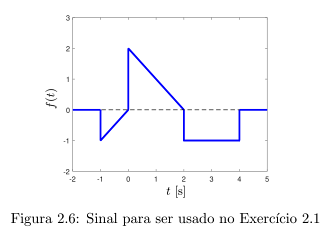
Apresente um esboço de cada um dos seguintes sinais:

a) $f(t-2)$.

b) $f(3-t)$.

c) $f(3-2 t)$.

**Comentários:** 
A questão **2.1** trata de algumas operações bastante comuns em sinais. Em particular, destacamos as operações elementares *deslocamento temporal, escalamento temporal* e *reversão temporal*, descritas abaixo e que, em geral, são combinadas. 

Inicialmente, vamos ilustrá-las através do sinal mais simples 

$$ f(t) = 
\begin{cases} 
e^{t/2}, \quad 1 \leq t < 5 \\ 0, \quad \text{caso contrário}
\end{cases},
$$
representado pelo gráfico abaixo:


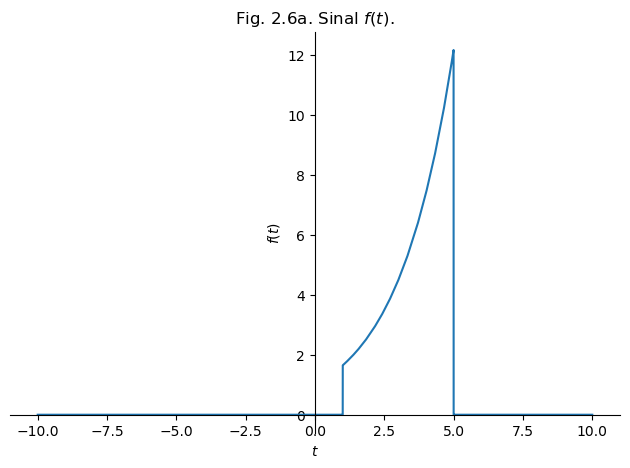

In [246]:
t = sym.Symbol('t')
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6a. Sinal $f(t)$.')

- Deslocamento temporal

No **deslocamento temporal** de um sinal por $T$ segundos, substituímos $t$ por $t − T$. Logo,  $x(t − T)$ representa $x(t)$ deslocado no tempo por $T$ segundos. 

Se $T$ for positivo, o deslocamento é para a direita (**atraso**). Se $T$ for negativo, o deslocamento é para a esquerda (**avanço**).

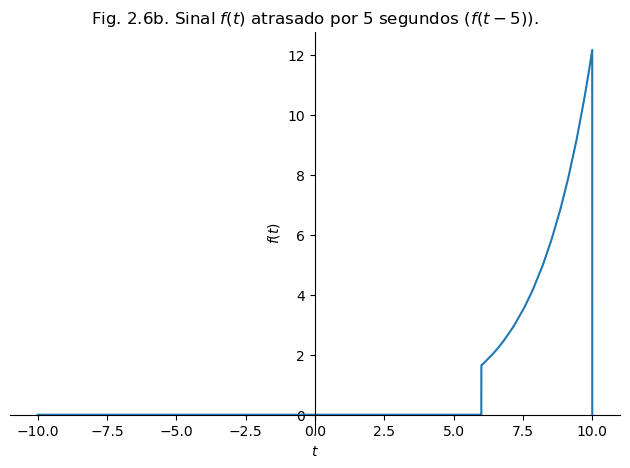

In [247]:
t = sym.Symbol('t')
a = 5
t = t - a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6b. Sinal $f(t)$ atrasado por %g segundos ($f(t - %g)$).' %(a,a))

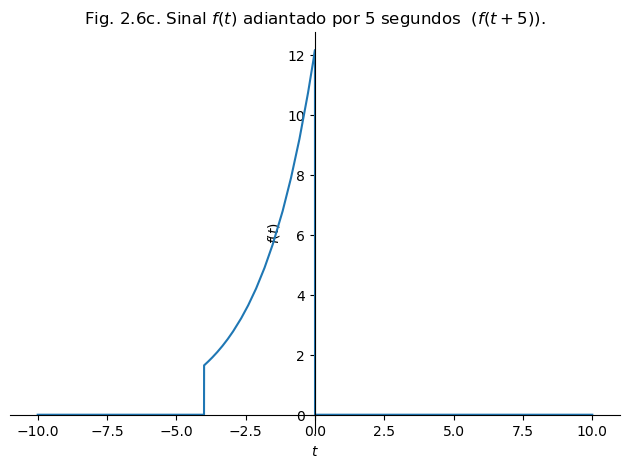

In [248]:
t = sym.Symbol('t')
a = 5
t = t + a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6c. Sinal $f(t)$ adiantado por %g segundos  ($f(t + %g)$).' %(a,a))

- Escalamento Temporal
 
A **compressão** ou **expansão** de um sinal no tempo é chamada de **escalamento temporal**. Considere o sinal $f(t)$ da Fig. 2.6a. 

O sinal da Fig. 2.6b é $x(t)$ comprimido no tempo por um fator de 2. Portanto, o que acontecer com $x(t)$ em algum instante $t$ também acontecerá com $\phi(t)$ no instante $t / 2$, logo

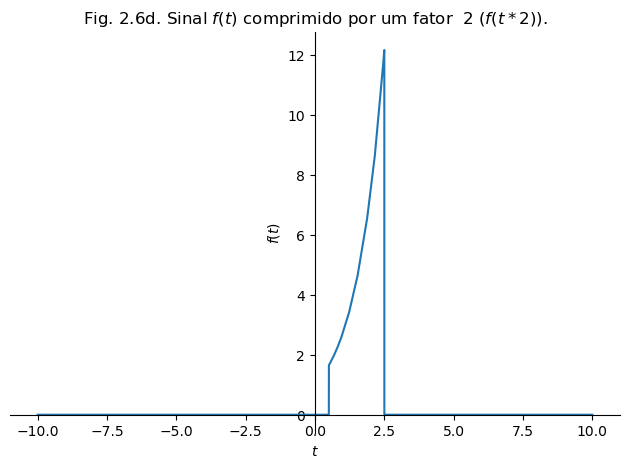

In [249]:
t = sym.Symbol('t')
a = 2
t = t*a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6d. Sinal $f(t)$ comprimido por um fator % g ($f(t*%g)$).' %(a,a))

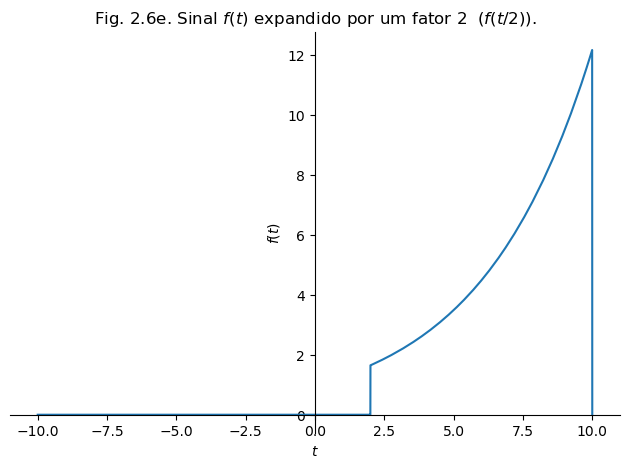

In [250]:
t = sym.Symbol('t')
a = 2
t = t/a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6e. Sinal $f(t)$ expandido por um fator %g  ($f(t/%g)$).' %(a,a))

- Reversão Temporal

Considere o sinal $f(t)$ da Fig. 2.6a. Podemos ver $f(t)$ como uma forma rígida presa ao eixo vertical. Na reversão temporal de $f(t)$, rotacionamos esta forma em $180^{\circ}$ com relação ao eixo vertical. Essa reversão temporal (a reflexão de $x(t)$ com relação ao eixo vertical) nos fornece o sinal $f(-t)$ (Fig. 2.6f). 

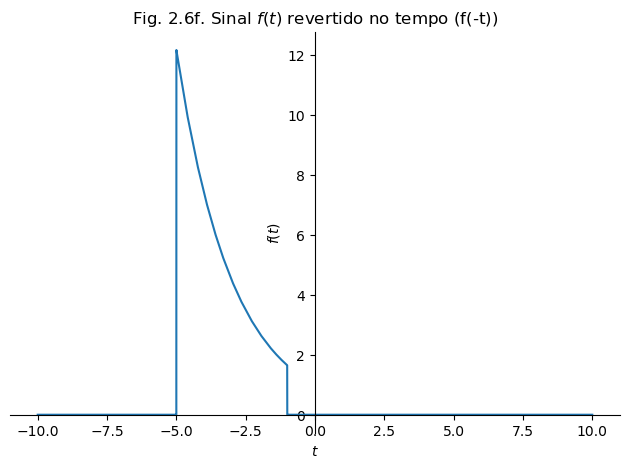

In [251]:
t = sym.Symbol('t')
t = -t
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6f. Sinal $f(t)$ revertido no tempo (f(-t))')

**Solução:**

O sinal da figura 2.6 pode ser escrito como 

$$ f(t) = 
\begin{cases} 
0, \quad -1 < t \\ 
t, \quad -1 \leq t < 0 \\
2 - t, \quad 0 \leq t < 2 \\
-1, \quad 2 \leq t < 4 \\
0, \quad 4 < t
\end{cases},
$$

representado na figura  2.6e, abaixo

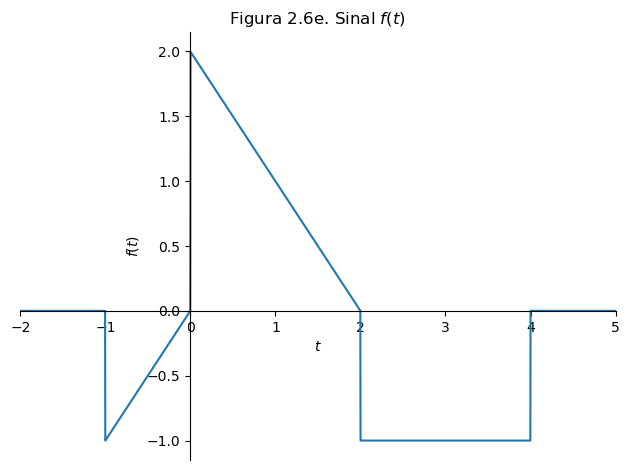

In [252]:
t = sym.Symbol('t')
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6e. Sinal $f(t)$', xlim = (-2,5))

Tem-se portanto, os seguintes sinais correspondentes:

a) $f(t-2)$.



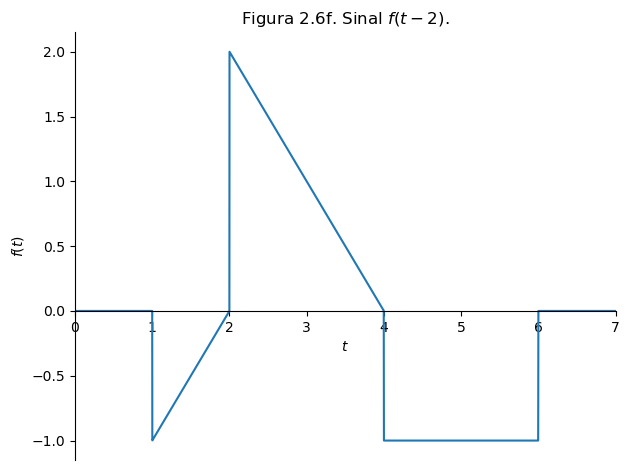

In [253]:
t = sym.Symbol('t')
a = 2
t = t - a
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6f. Sinal $f(t - %a)$.' %a, xlim = (0,7))

b) $f(3-t)$.

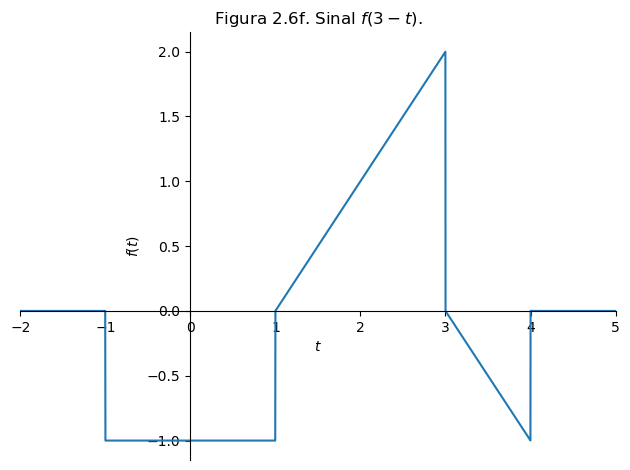

In [254]:
t = sym.Symbol('t')
a = 3
t = a - t
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6f. Sinal $f(%g - t)$.' %a, xlim = (-2,5))

c) $f(3-2 t)$.

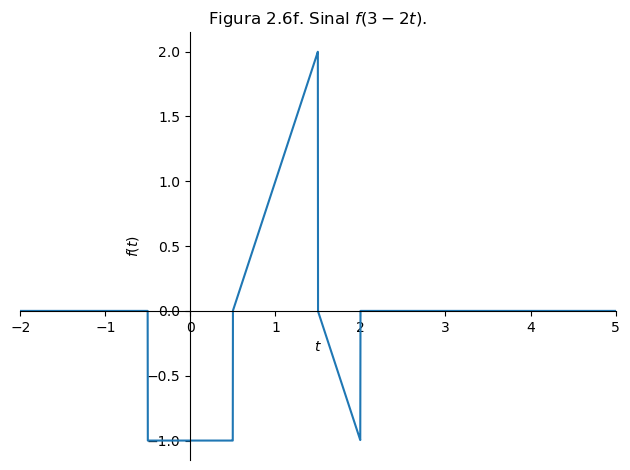

In [255]:
t = sym.Symbol('t')
a = 3
b = 2
t = a - b*t
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6f. Sinal $f(%g - %g t)$.' %(a,b), xlim = (-2,5))

**Exercício 2.2** Considere o sinal $f(t)=e^{j \omega_1 t}+e^{j \omega_2 t}$ com dominio $\mathbb{R}$. Mostre que para este sinal ser periódico é necessário que a relação $\omega_1 / \omega_2$ seja um número racional. Se isto ocorrer, qual é o seu período? Aplique o resultado nos seguintes casos:

a) $\omega_1=2$ e $\omega_2=3$.

b) $\omega_1=2 \pi$ e $\omega_2=3 \pi$.

c) $\omega_1=2 / \pi$ e $\omega_2=3 / \pi$.

**Solução:**

Vamos denotar $f(t) = s_1(t) + s_2(t)$, onde $s_1(t) = e^{j \omega_1 t}$ e $s_2(t) = e^{j \omega_2 t}$.

Usando a identidade de Euler, tem-se que 

$$s_1(t) = cos(\omega_1 t) + jsin(\omega_1 t)$$

e

$$s_2(t) = cos(\omega_2 t) + jsin(\omega_2 t)$$

de onde se observa que os sinais $s_1(t)$ e $s_2(t)$ são periódicos com períodos fundamentais dados, respectivamente, por

$$ T_1 = \frac{2 \pi}{\omega_1} \text{ e } T_2 = \frac{2 \pi}{\omega_2}.$$

Como o período fundamental é o menor período e os múltiplos dos períodos fundamentais são períodos, o mínimo múltiplo comum entre $T_1$ e $T_2$ (caso exista) é o período fundamental de $f(t)$, isto é

$$f(t + T) = f(t), \quad \forall t \in \mathcal{D}(f), $$

com $T = mmc\{T_1,T_2\}$.

Assim, tem-se que devem existir dois inteiros $m,n \in \mathbb{N}$, tal que $T = mT_1 = nT_2$.
Donde de infere que $\frac{T_1}{T_2} = \frac{n}{m} \in \mathbb{Q}$ $\square$.

Temos portanto:

a) $\omega_1=2$ e $\omega_2=3$.

In [256]:
lcm_float(2,3,2)

6.0

b) $\omega_1=2 \pi$ e $\omega_2=3 \pi$.

Resposta: $T = 6 \pi$

c) $\omega_1=2 / \pi$ e $\omega_2=3 / \pi$.

Resposta: $T = 6 / \pi$.

**Exercício 2.3** Verifique se os seguintes sinais com dominio $\mathbb{R}$ são periódicos. Em caso afirmativo, determine o respectivo período.

a) $f(t)=\cos (\sqrt{2} t)$

b) $f(t)=2 \cos (3 t+2)-3 \sin(4 t-1)$

c) $f(t)=\cos (t)+\cos (\sqrt{2} t)$

d) $f(t)=e^{j(2 \pi / 3) t}$


e) $f(t)=e^{(-1+j 2 \pi / 3) t}$

f) $f(t)=e^{j t}+2 e^{j t / 3}$

g) $f(t)=\sum_{k=0}^{10} e^{j(\pi / 2) k t}$

h) $f(t)=\operatorname{sen}(2 \pi t)+\cos (5 \pi t)+\operatorname{sen}(3 \pi t)$

**Solução**

a) $f(t)=\cos (\sqrt{2} t)$: periódico com período $T = \frac{2\pi}{\sqrt{2}} = \pi \sqrt{2}.$

b) $f(t)=2 \cos (3 t+2)-3 \sin(4 t-1)$: como se trata de uma soma de funções periódicas com períodos dados por $T_1 = \frac{2 \pi}{3}$ e $T_2 = \frac{\pi}{2}$, o sinal $f(t)$ é periódico de período $T = 2 \pi$, como se observa nas figuras abaixo:

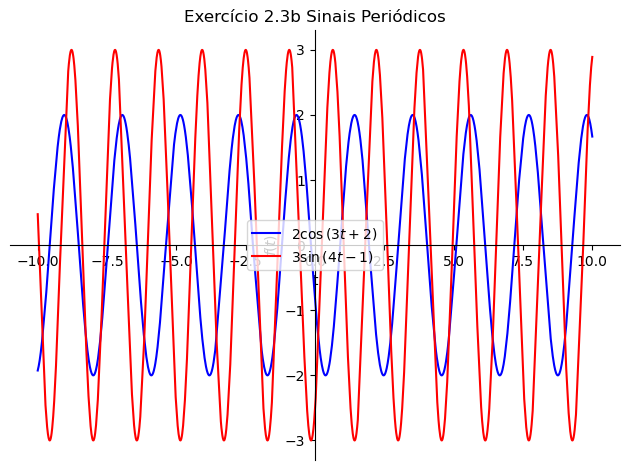

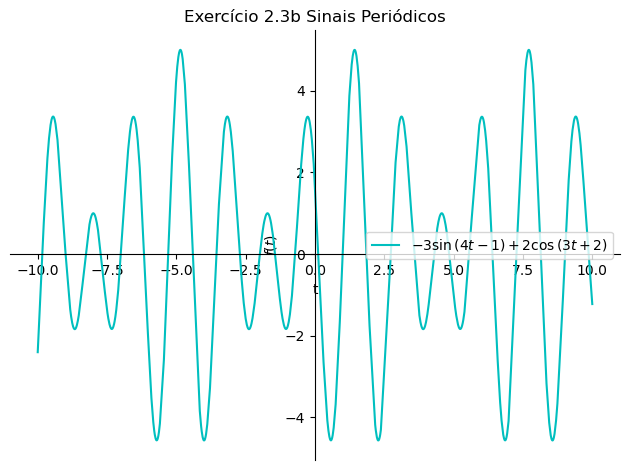

(None, None)

In [257]:
t = sym.Symbol('t')

s1 = 2*cos(3*t + 2)
s2 = 3*sin(4*t -1)

p1 = sym.plot(s1, s2, \
              title='Exercício 2.3b Sinais Periódicos', xlabel='t', legend=True, show=False)
p2 = sym.plot(s1 - s2, \
              title='Exercício 2.3b Sinais Periódicos', xlabel='t', legend=True, show=False)
p1[0].line_color = 'b'
p1[1].line_color = 'r'
p2[0].line_color = 'c'
p1.show(), p2.show()

c) $f(t)=\cos (t)+\cos (\sqrt{2} t)$: como $T_1 = 2 \pi$ e $T_2 = \sqrt{2} \pi$, $\frac{T_1}{T_2} \notin \mathbb{Q}$ e o sinal é aperiódico.

d) $f(t)=e^{j(2 \pi / 3) t}$: periódica com período $T = 3.$


e) $f(t)=e^{(-1+j 2 \pi / 3) t} = e^{-t}e^{(j 2 \pi / 3) t}$, que é o produto de um sinal aperiódico por um sinal periódico, que é aperiódico. Como o sinal $f(t)$ é complexo, vamos ilustrar suas partes real e complexa, nos gráficos abaixo:

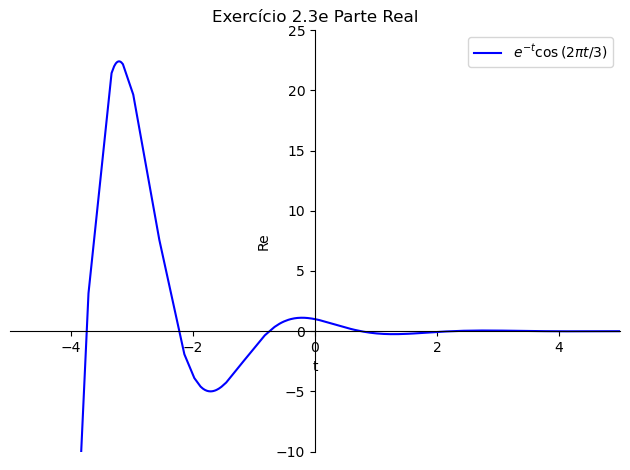

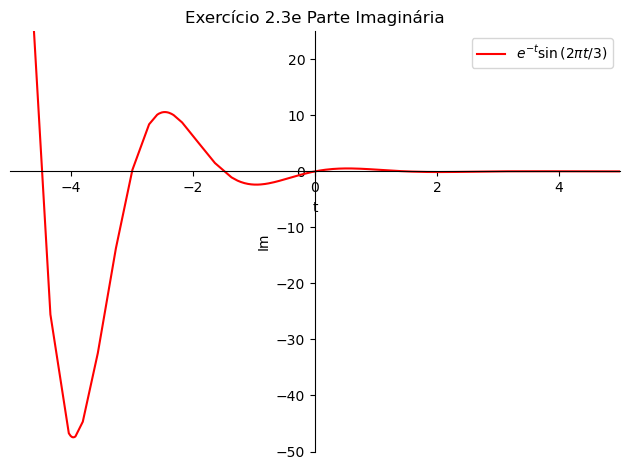

(None, None)

In [258]:
t = sym.Symbol('t')

s1 = exp(-t)*cos(2*pi*t/3)
s2 = exp(-t)*sin(2*pi*t/3)

p1 = sym.plot(s1, title='Exercício 2.3e Parte Real', xlim = (-5,5), ylim = (-10,25), xlabel='t', ylabel = 'Re', legend=True, show=False)
p2 = sym.plot(s2, title='Exercício 2.3e Parte Imaginária', xlim = (-5,5), ylim = (-50,25), xlabel='t', ylabel = 'Im', legend=True, show=False)
p1[0].line_color = 'b'
p2[0].line_color = 'r'
p1.show(), p2.show()

f) $f(t)=e^{j t}+2 e^{j t / 3}$

Neste caso temos a soma de dois sinais complexos periódicos, $f(t) = f_1(t) + f_2(t)$, onde $f_1(t) = e^{j t}$ tem período $T_1 = 2\pi$ e $f_2(t) = e^{j t/3}$ tem período $T_2 = 6\pi.$ Considerando o $mmc(2, 6) = 6$, tem-se que o sinal é periódico com período $T = 6\pi$. Abaixo, apresetamos as partes real e complexa do sinal em questão. 

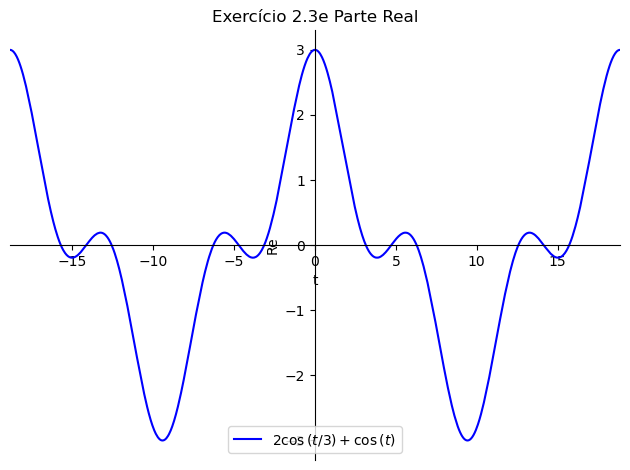

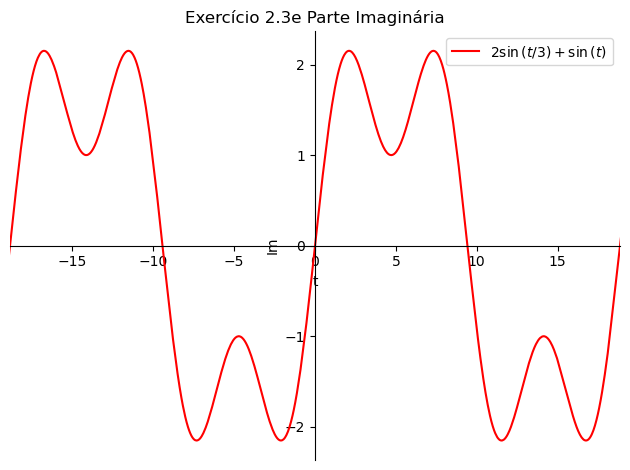

(None, None)

In [259]:
t = sym.Symbol('t',real=True)

s1 = cos(t) + 2*cos(t/3)
s2 = sin(t) + 2*sin(t/3)

p1 = sym.plot(s1,(t,-21,21), title='Exercício 2.3e Parte Real', xlim = (-6*pi,6*pi), xlabel='t', ylabel ='Re', legend=True, show=False)
p2 = sym.plot(s2,(t,-21,21), title='Exercício 2.3e Parte Imaginária',xlim = (-6*pi,6*pi), xlabel='t', ylabel ='Im', legend=True, show=False)
p1[0].line_color = 'b'
p2[0].line_color = 'r'
p1.show(), p2.show()

g) $f(t)=\sum_{k=0}^{10} e^{j(\pi / 2) k t}$

Neste caso, podemos escrever  $f(t)=1 + \sum_{k=1}^{10} e^{j(\pi / 2) k t}$, ou seja, uma constante, mais a soma de nove sinais periódicos, com períodos $T_k = 4/k, \quad \forall k = 1, \cdots, 10$. Como o mmc entre os períodos é $T = 4,$ temos um sinal períódico, como apresentado na figura abaixo.

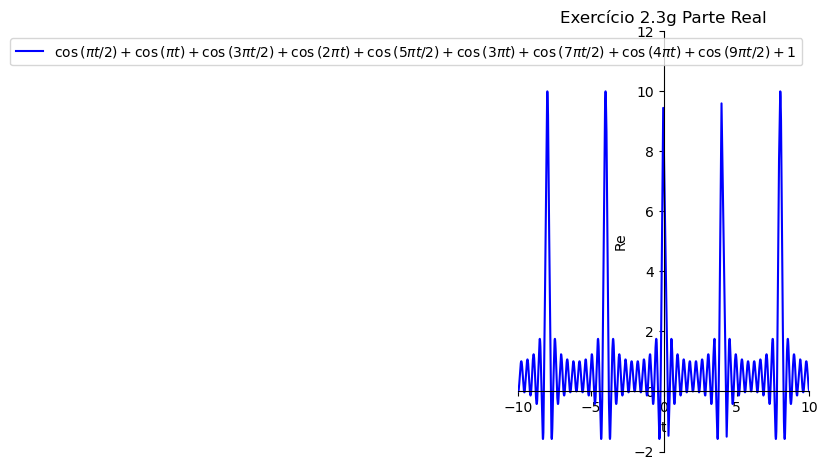

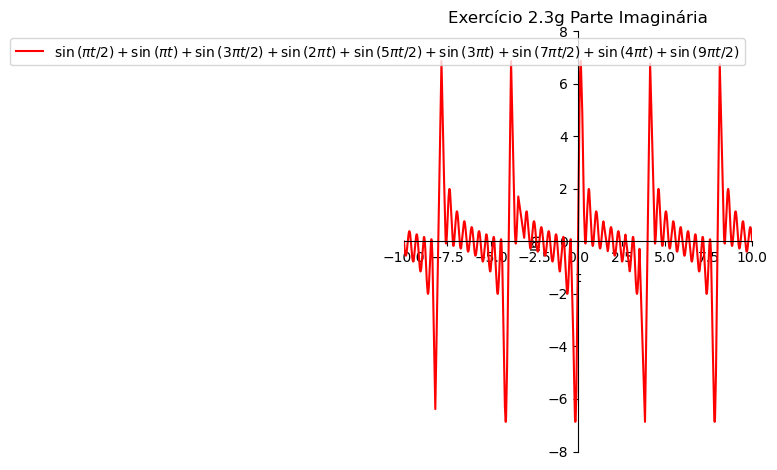

(None, None)

In [260]:
t = sym.Symbol('t',real=True)
s1 = 1
s2 = 0
for k in range(1,10):
    s1 = s1 + cos(k*pi*t/2)
    s2 = s2 + sin(k*pi*t/2)

p1 = sym.plot(s1,title='Exercício 2.3g Parte Real', xlim = (-10,10), ylim = (-2,12), xlabel='t', ylabel ='Re', legend=True, show=False)
p2 = sym.plot(s2, title='Exercício 2.3g Parte Imaginária', xlim = (-10,10), ylim = (-8,8),  xlabel='t', ylabel ='Im', legend=True, show=False)
p1[0].line_color = 'b'
p2[0].line_color = 'r'
p1.show(), p2.show()

h) $f(t)=\sin (2 \pi t)+\cos (5 \pi t)+\sin(3 \pi t)$
De modo análogo aos exercícios acima, este sinal é periódico com período $T = mmc\{1, \frac{2}{5},\frac{2}{3}\} = 2$, como vemos no gráfico abaixo:

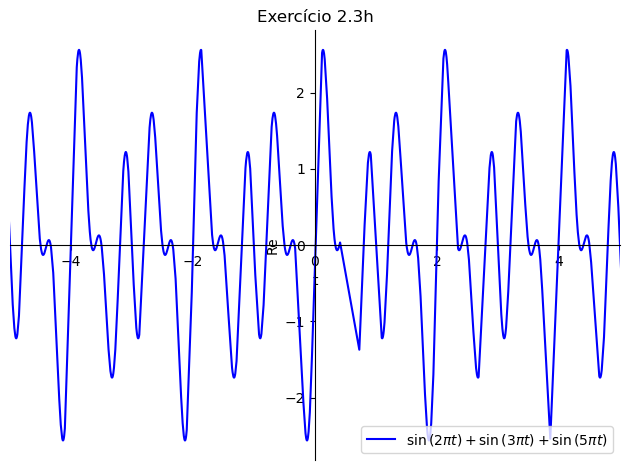

In [261]:
t = sym.Symbol('t',real=True)
s1 = sin(2*pi*t) + sin(5*pi*t) + sin(3*pi*t)
p1 = sym.plot(s1,title='Exercício 2.3h', xlim = (-5,5), xlabel='t', ylabel ='Re', legend=True, show=False)
p1[0].line_color = 'b'
p1.show()

**Exercício 2.4** Para os sinais a tempo discreto dados abaixo e definidos para todo $k \in$ $\mathbb{Z}$, verifique quais são periódicos e determine seus respectivos periodos.

a) $f(k)=\cos (\sqrt{2} k)$

b) $f(k)=\cos (8 \pi k / 31+2)$

c) $f(k)=2 \cos (3 \pi k+2)-3 \sin (2 \pi k / 3-1)$

d) $f(k)=e^{(-1+j 2 \pi / 3) k}$

e) $f(k)=e^{j \pi k}+2 e^{j(\pi / 3) k}$

f) $f(k)=1+e^{j(4 \pi / 9) k}+e^{j(2 \pi / 5) k}$

**Comentários:** além das condições estudadas para sinais a tempo contínuo, o período para sinais a tempo discreto deve ser um número natural.

a) $f(k)=\cos (\sqrt{2} k)$. Neste caso, como $\sqrt{2}N = 2 \pi$, segue que $N \notin \mathbb{N}$ e, portanto, o sinal é aperiódico. 

b) $f(k)=\cos\left(\frac{8 \pi k}{31}+2\right)$. Fazendo $\frac{4}{31} \cdot 2 \pi N - 2 = 2\pi$ passando o -$2$ para o outro lado e dividindo ambos os lados por $2\pi$ temos: $$\frac{4N}{31} = \frac{\pi + 1}{\pi}$$ e isolando o N temos que $$N = \frac{31\pi + 31}{4\pi} \notin \mathbb{N}$$

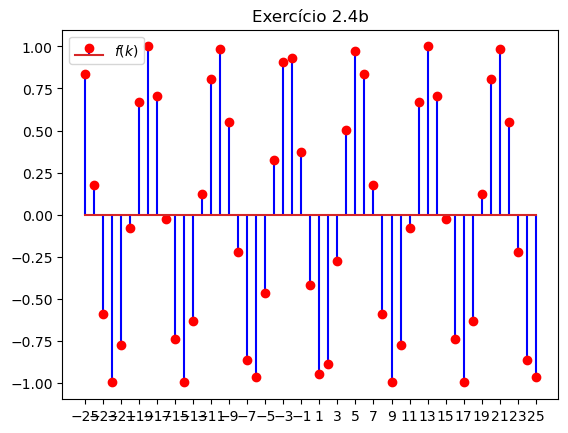

In [262]:
z = []
s1 = []
for k in range(-25,26):
    z.append(k)
    s1.append(cos((8/31)*pi*k + 2))
    
plt.stem(z, s1, 'b', markerfmt='ro', label='$f(k)$')
plt.legend()
plt.title('Exercício 2.4b')
plt.xticks(range(-25,26,2))
plt.show()

c) $f(k)=2 \cos (3 \pi k+2)-3 \sin (2 \pi k / 3-1)$. Neste caso, temos a soma de dois sinais: $s_1(k) = 2 \cos (3 \pi k+2)$, com período $N_1 = 2/3$, e $s_2(k) = 3 \sin (2 \pi k / 3-1)$, com período e $N_2 = 3$. O período de $f(k)$ é dado por $N = mmc\{2/3,3\} = 6$. Como pode ser depreendido do gráfico abaixo

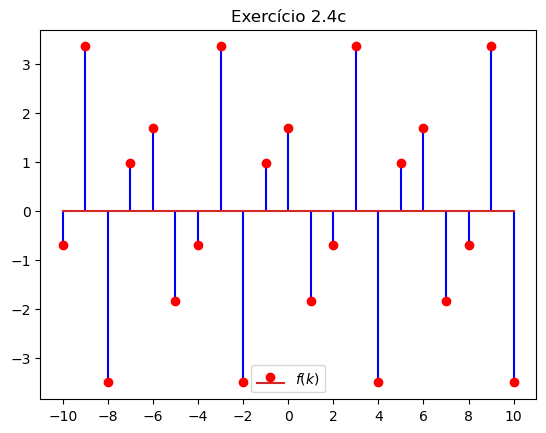

In [263]:
z = []
s1 = []
s2 = []
for k in range(-10,11):
    z.append(k)
    s1.append(2*cos(3*pi*k + 2))
    s2.append(3*sin(2*pi*k/3 - 1))
    
f = [(a - b) for a, b in zip(s1, s2)]
plt.stem(z, f, 'b', markerfmt='ro', label='$f(k)$')
plt.legend()
plt.title('Exercício 2.4c')
plt.xticks(range(-10,11,2))
plt.show()

d) $f(k)=e^{(-1+j \frac{2\pi}{3}) k}$, assim como no caso de tempo contínuo, podemos separar o sinal em $f(k)= e^{-k} \cdot e^{j \frac{2\pi}{3} k}$ e sabemos que e^{(-k)} não é um sinal periódico, portanto, o produto dos dois sinais é um sinal não periódico.

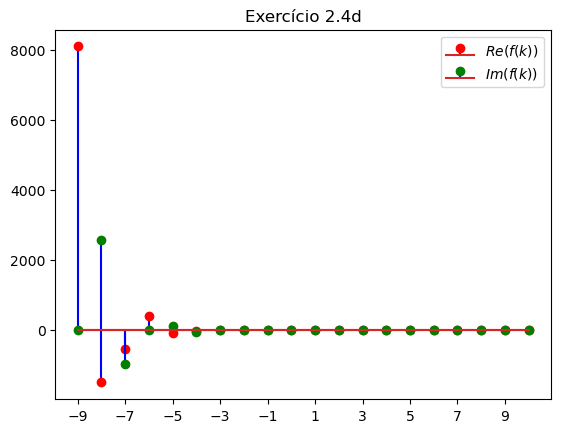

In [264]:
z = []
s1 = []
s2 = []
for k in range(-9,11):
    z.append(k)
    s1.append(exp(-k)*cos((2*pi*k)/3))
    s2.append(exp(-k)*sin((2*pi*k)/3))
    
plt.stem(z, s1, 'b', markerfmt='ro', label='$Re(f(k))$')
plt.stem(z, s2, 'b', markerfmt='go', label='$Im(f(k))$')
plt.legend()
plt.title('Exercício 2.4d')
plt.xticks(range(-9,11,2))
plt.show()

e) $f(k)=e^{j \pi k}+2 e^{j(\pi / 3) k}$. Neste caso, o sinal é dado pela soma de dois sinais complexos $s_1(k)  = e^{j \pi k}$, com período $N_1 = 2$ e $s_2(k)  = e^{j(\pi / 3) k}$, com período $N_2 = 6$. O período de $f(k)$ é, portando $N = mmc\{2,6\} = 6$. Abaixo apresentamos os gráficos das partes real e imaginária de $f(k)$.


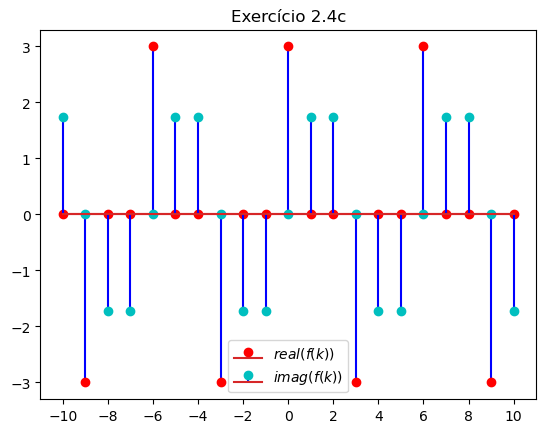

In [265]:
z = []
s1 = []
s2 = []
for k in range(-10,11):
    z.append(k)
    s1.append(cos(pi*k) + 2*cos(pi*k/3))
    s2.append(sin(pi*k) + 2*sin(pi*k/3))
    
plt.stem(z, s1, 'b', markerfmt='ro', label='$real(f(k))$')
plt.stem(z, s2, 'b', markerfmt='co', label='$imag(f(k))$')
plt.legend()
plt.title('Exercício 2.4c')
plt.xticks(range(-10,11,2))
plt.show()

f) $f(k)=1+e^{j\frac{4\pi}{9}k}+e^{j\frac{2\pi}{5}k}$ é a combinação do sinal constante $1$ e os sinais periódicos $e^{j\frac{4\pi}{9}k}$ e $+e^{j\frac{2\pi}{5}k}$, de período $N_0 = 9$ e $N_0 = 5$ respectivamente. O sinal, portanto, é periódico com período $N_0 = 45$

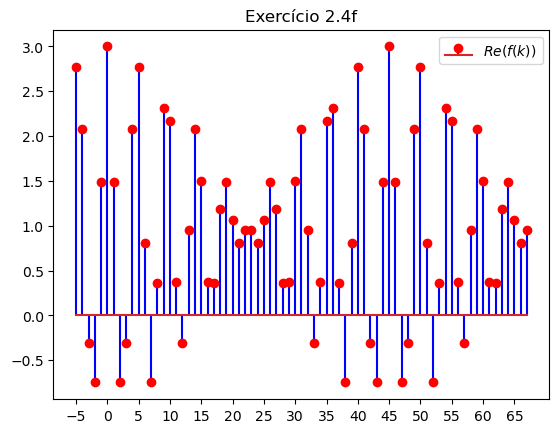

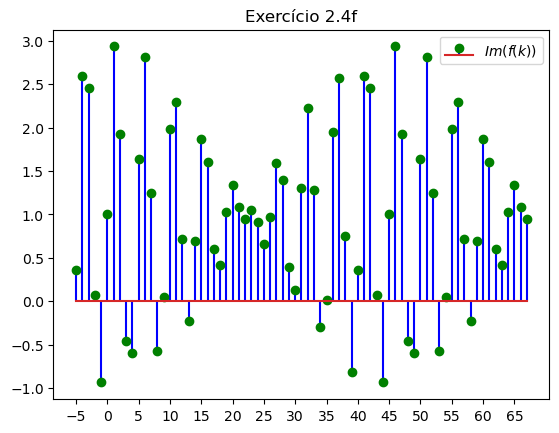

In [266]:
z = []
s1 = []
s2 = []
for k in range(-5,68):
    z.append(k)
    s1.append(cos(4*pi*k/9))
    s2.append(cos(2*pi*k/5))
    
f = [(1 + a + b) for a, b in zip(s1, s2)]
plt.stem(z, f, 'b', markerfmt='ro', label='$Re(f(k))$')
plt.legend()
plt.title('Exercício 2.4f')
plt.xticks(range(-5,68,5))
plt.show()

z = []
s1 = []
s2 = []
for k in range(-5,68):
    z.append(k)
    s1.append(sin(4*pi*k/9))
    s2.append(sin(2*pi*k/5))
    
f = [(1 + a + b) for a, b in zip(s1, s2)]
plt.stem(z, f, 'b', markerfmt='go', label='$Im(f(k))$')
plt.legend()
plt.title('Exercício 2.4f')
plt.xticks(range(-5,68,5))
plt.show()

**Exercício 2.5** Mostre que a relação $\int_{-\infty}^{\infty} f(t) \delta(t-\tau) d t=f(\tau)
$ é verdadeira. Em seguida, generalize este resultado e mostre que para $\alpha \in \mathbb{R}_{+}$ e $\tau \in \mathbb{R}$ a igualdade
$$
\int_{-\infty}^{\infty} f(t) \delta(\alpha t-\tau) d t=f(\tau / \alpha) / \alpha
$$
também é verdadeira.


**Solução:** Sendo $f(t)$ um sinal contínuo em $t=0$ e, por definição $\delta(t) \equiv 0, \quad \forall t \neq 0,$ temos que 
$$f(t)\delta(t) = f(0)\delta(t).$$
Segue-se, portanto que 
$$
\int_{-\infty}^{\infty} f(t) \delta(t-\tau) d t=  f(\tau)\int_{-\infty}^{\infty}  \delta(t-\tau) d t=f(\tau).
$$

Este resultado é conhecido como **Propriedade de amostragem do impulso unitário**.

Para demonstrar a propriedade requerida, note que 
$$
\int_{-\infty}^{\infty} f(t) \delta(\alpha t-\tau) d t=f(\tau / \alpha) \int_{-\infty}^{\infty} \delta(\alpha t-\tau) d t.
$$

Propondo a mudança de variáveis $\hat{t} = \alpha t - \tau$, temos que 

$$
f(\tau / \alpha) \int_{-\infty}^{\infty} \delta(\alpha t-\tau) d t = f(\tau / \alpha)\int_{-\infty}^{\infty} \delta(\hat{t}) \frac{d \hat{t}}{\alpha} = \frac{f(\tau / \alpha)}{\alpha}. \qquad \blacksquare
$$


**Exercício 2.6** Para os sinais a tempo contínuo dados abaixo, determine sua energia total $E$ e sua potência média $P$.

a) $f(t)=\alpha$ para todo $t \in \mathbb{R}$ e $\alpha \in \mathbb{R}$.

Como se trata de um sinal constante, temos que $E(f) = \infty$ e $P(f) = |\alpha|$.

b) $f(t)=e^{-|t|}$ para todo $t \in \mathbb{R}$.

$$e^2 = \int_{-\infty}^{\infty} e^{-2t} dt$$ 
$$=\frac{e^{-2t}}{-2} |_{-\infty}^{\infty} = \frac{e^{2\infty} - e^{-2\infty}}{2} = senh(2\infty)$$ 
$$\therefore E = \infty$$

$P^2 = lim_{T \rightarrow \infty}\frac{1}{2T}\int_{-T}^{T} e^{-2t}$. Utilizando o resultado anterior sabemos que a integral do sinal ao quadrado equivale à $senh(2t)$, que multiplicada com $\frac{1}{2T}$ é igual a: $$\frac{senh(2t)}{2T}$$ Substituindo os limites de integração e checando o limite vemos que: $$lim_{T \rightarrow \infty}\frac{senh(2T)}{2T} \rightarrow \infty$$

In [267]:
t = sym.Symbol('t')
T = sym.Symbol('T')
f = exp(-t)

integrate(f*f, (t, -oo, oo))

oo

In [268]:
limit(integrate(f*f, (t, -T, T))/(2*T),T,oo)

oo

c) $f(t)=0$ para $t<0$ e $f(t)=e^{-2 t}$ para $t \geq 0$.

Neste caso, temos

- $E^2(f) = \int_{-\infty}^{\infty} |f(t)|^2 dt = \int_{0}^{\infty}e^{-4 t} dt$

- $P^2(f) = lim_{T \rightarrow \infty}\frac{1}{2T}\int_{-T}^{T} |f(t)|^2 dt = lim_{T \rightarrow \infty}\frac{1}{2T}\int_{0}^{T} e^{-4 t} dt$

In [269]:
f = exp(-2*t)

E = sqrt(integrate(f*f,(t,0,+oo)))
E

1/2

In [270]:
P = sqrt(limit(integrate(f*f,(t,0,+T))/(2*T),T,oo ))
P
integrate(f*f,(t,0,+T))/(2*T)

(1/4 - exp(-4*T)/4)/(2*T)

d) $f(t)=e^{(1+j) t}$ para $t<0$ e $f(t)=0$ para $t \geq 0$.

$E^2 = \int_{-\infty}^{0} e^{2t+j2t} dt$ substituindo $2t+j2t$ por $u$ temos que $du = (2+j2)dt$
$$\frac{1}{2+j2} \int_{-\infty}^{0} e^u du$$ 
$$\therefore \frac{1}{4} + \frac{1}{j4} \cdot (e^0 - e^{-\infty})$$
$$\therefore E = \frac{\sqrt{1-j}}{2}$$

In [271]:
f = exp(t+I*t)
sqrt(integrate(f*f, (t, -oo, 0))).simplify()


sqrt(1 - I)/2

$P^2 = lim_{\tau \rightarrow \infty}\frac{1}{2\tau}\int_{-\tau}^{0} e^{2t+j2t} dt$   
Como já calculamos anteriormente, a integral da função, de $-\tau$ à $0$ é: $$\frac{1}{4} + \frac{1}{j4} \cdot (e^0 - e^{-\tau})$$
$$\therefore \frac{1}{2\tau} \cdot \left( \frac{1}{4} + \frac{1}{j4} \right) \cdot (e^0 - e^{-\tau})$$ 
$$ = \left( \frac{1}{8\tau} + \frac{1}{j8\tau} \right) \cdot (1 - e^{-\tau}) = g(\tau)$$

analizando o limite $lim_{\tau \rightarrow \infty}$ temos um termo que vai à zero multiplicanto outro termo, portanto, podemos dizer de cara que o limite tende à zero. Logo: 

$$P = \sqrt{lim_{\tau \rightarrow \infty} g(\tau)} \therefore P= 0$$

In [272]:
integrate(f*f, (t, -T, 0))/(2*T).simplify()

(1/4 - I/4 - exp(-2*T)*exp(-2*I*T)/4 + I*exp(-2*T)*exp(-2*I*T)/4)/(2*T)

In [273]:
y = (1/(2*T))*(1/(4) + 1/(4*I)) * (1 - exp(-T))
y.simplify()

(1.0 - I)*(exp(T) - 1)*exp(-T)/(8*T)

In [274]:
sqrt(limit(y, T, oo))

0

**Exercício 2.7** Considere o sinal $f(t)=e^{t+1} v(-t-1)$ definido para tado $t \in \mathbb{R}$.

a) Esboce a sua componente par $f_p(t)$ e a sua componente ímpar $f_i(t)$.

b) Determine a energia total do sinal $E$ e de suas componentes par $E_p$ e ímpar $E_i$.

c) Qual e a relação que existe entre $E_p$ e $E_i$? Determine para qual classe de sinais esta relação permanece válida.



**Solução:** Vamos escrever $f(t) = g(t)h(t),$ onde $g(t) = e^{t+1}$ e $h(t) = v(-t-1)$

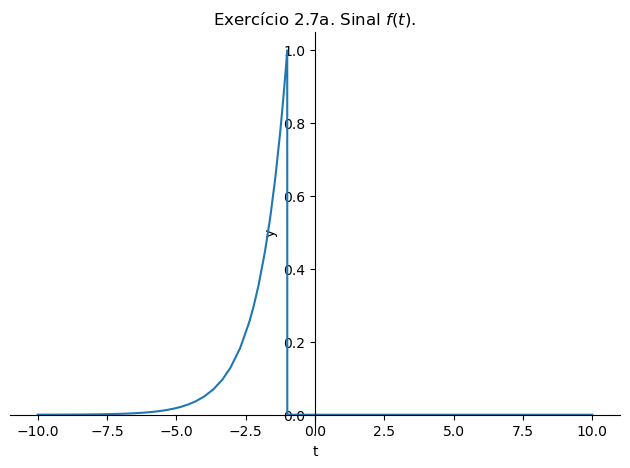

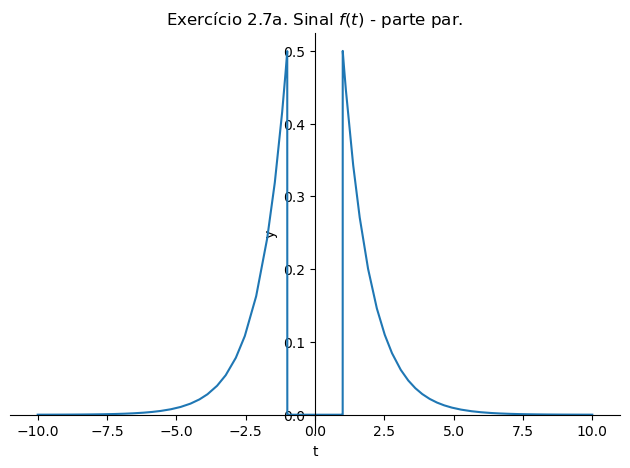

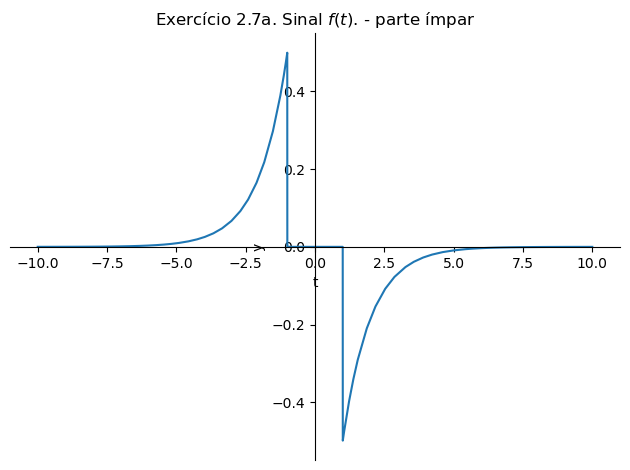

(None, None, None)

In [275]:
t = sym.Symbol('t')

g = exp(t + 1)
gm = exp(-t + 1) # para a componente ímpar
h = sym.Piecewise((1, -1 >= t), (0, True))
hm = sym.Piecewise((1, 1 <= t), (0, True)) # para a componente ímpar
f = g*h
fm = gm*hm

fp = 0.5*(f + fm)
fi = 0.5*(f - fm)
p1 = sym.plot(f, title='Exercício 2.7a. Sinal $f(t)$.', xlabel='t', ylabel ='y', show=False)

p2 = sym.plot(fp, title='Exercício 2.7a. Sinal $f(t)$ - parte par.', xlabel='t', ylabel ='y', show=False)

p3 = sym.plot(fi, title='Exercício 2.7a. Sinal $f(t)$. - parte ímpar', xlabel='t', ylabel ='y', show=False)

p1.show(), p2.show(), p3.show()


In [276]:
t = sym.Symbol('t')
f = exp(t + 1)

E = (integrate(f*f,(t,-oo,-1)))
E

1/2

In [277]:
t = sym.Symbol('t')
g = 0.5*exp(t + 1)
gm = 0.5*exp(-t + 1)
Ep = (integrate(g*g,(t,-oo,-1)) + integrate(gm*gm,(t,1,+oo)))
Ep

0.250000000000000

In [278]:
t = sym.Symbol('t')
g = 0.5*exp(t + 1)
gm = -0.5*exp(-t + 1)
Ei = (integrate(g*g,(t,-oo,-1)) + integrate(gm*gm,(t,1,+oo)))
Ei

0.250000000000000

No presente exercício, tem-se que $E^2 = E_p^2 + E_i^2$. 

Como provamos (em sala da aula) que a parte par e a parte ímpar de um sinal (complexo) são ortogonais, temos que 

$$
E^2 = \langle  f\; , \;f^* \rangle =  \langle  (f_p + f_i)\; , \;(f_p + f_i)^* \rangle = |f_p|^2 + |f_i|^2,
$$

De onde segue-se que $E^2 = E_p^2 + E_i^2$, para sinais a tempo contínuo.

**Exercício 2.8** Considere um circuito $R C$ série com constante de tempo $\tau=0.5[\mathrm{~s}]$, alimentado por uma fonte de tensão $f(t)$. Em $t=0$ a tensão no capacitor é nula e a fonte é conectada. Determine a energia total $E$ e a potência média $P$ da tensão produzida no capacitor $f_c(t)$, considerando

a) $f(t)=10[\mathrm{~V}]$ para todo $t \geq 0$.

b) $f(t)=10 \operatorname{sen}(t / 4)[\mathrm{V}]$ para todo $t \geq 0$.


a equação característica para um circuito RC é dada por $ g(t) = f(t) \cdot \left( 1 - e^{\frac{-t}{\tau}} \right)$
logo a energia total é dada por $E^2 = \int_{-\infty}^{\infty} g(t)^2 dt$

a) para $f(t) = 10$

In [279]:
f = 10
g = f * (1 - exp(-t/.5))
sqrt(integrate(g*g, (t, -oo, oo)))

oo

e $P^2 = lim_{\tau \rightarrow \infty}\frac{1}{2\tau}\int_{-\tau}^{\tau} g(t)^2 dt$   


In [280]:
sqrt(limit(integrate(g*g, (t, -a, a))/(2*a), a, oo))

819.463966448743

b) para $f(t) = 10\sin{\left(\frac{t}{4} \right)}$

In [281]:
c = 10
f = sin(t/4)
g = f * (1 - exp(-t/.5))

c**2 * integrate(g*g, (t, -oo, oo))

100*Integral((1 - exp(-2.0*t))**2*sin(t/4)**2, (t, -oo, oo))

In [282]:
c**2 * integrate(g*g, (t, -oo, oo)).evalf()

0.e+792877141503349834877822289533239937662511623401870050607793850467977160806820650287131931929262830246562

In [283]:
z = c**2 * integrate(g*g, (t, -a, a))
sqrt(limit(z/(2*a), a, oo)).evalf()

521.053482357656